In [ ]:
# --- Imports and Setup for MNIST Flow Matching
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import math
from sklearn.datasets import make_moons, make_circles

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")


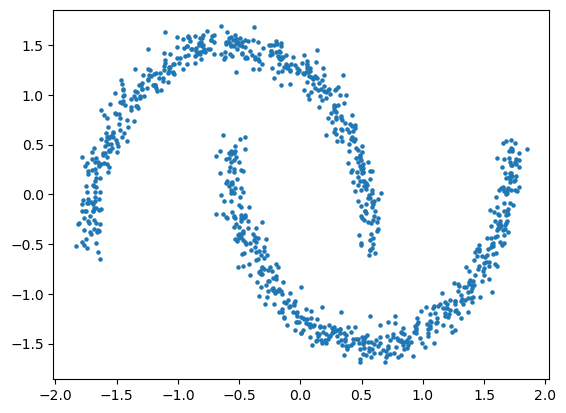

In [150]:
X, _ = make_moons(n_samples=1000, noise=0.05)
X = torch.tensor(X, dtype=torch.float32)
data_mean = X.mean(dim=0)
data_std = X.std(dim=0)
X = (X - data_mean) / data_std  # normalize to mean 0, std 1

plt.scatter(X[:, 0], X[:, 1], s=5)
plt.show()

def sample_data(batch_size):
    idx = torch.randint(0, len(X), (batch_size,))
    return X[idx]

def sample_noise(batch_size):
    return torch.randn(batch_size, 2)



In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import math
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons

device = "cuda" if torch.cuda.is_available() else "cpu"


# -----------------------
# Flow Model
# -----------------------
class Flow(nn.Module):
    def __init__(self, input_dim=2, time_dim=128, hidden_dim=256):
        super().__init__()
        self.input_dim = input_dim
        self.time_dim = time_dim
        self.hidden_dim = hidden_dim

        self.point_embedding = nn.Linear(input_dim, hidden_dim)

        # Time embedding + MLP like in Diffusion Models
        self.time_mlp = nn.Sequential(
            nn.Linear(time_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, hidden_dim),
        )

        self.main = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, input_dim)
        )

    def sinusoidal_time_embedding(self, t):
        """
        t: [B] -> [B, time_dim]
        """
        half_dim = self.time_dim // 2
        freqs = torch.exp(
            -math.log(10000) * torch.arange(0, half_dim, device=t.device) / half_dim
        )
        args = t.unsqueeze(-1) * freqs  # [B, half_dim]
        return torch.cat([torch.sin(args), torch.cos(args)], dim=-1)

    def forward(self, x, t):
        # x: [B, 2], t: [B]
        x_emb = self.point_embedding(x)         # [B, hidden_dim]

        t_emb = self.sinusoidal_time_embedding(t)  # [B, time_dim]
        t_emb = self.time_mlp(t_emb)            # [B, hidden_dim]

        h = x_emb + t_emb                       # Combine point + time features
        return self.main(h)                     # Predicted flow vector
        

# -----------------------
# Training Loop
# -----------------------
batch_size = 256
n_epochs = 3000
lr = 1e-3

model = Flow().to(device)
optimizer = optim.Adam(model.parameters(), lr=lr)

# Learning Rate Scheduler - Cosine Annealing with Warm Restarts
scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer, 
    T_0=500,        # Period of first restart
    T_mult=2,       # Factor to increase T_i after each restart
    eta_min=1e-6    # Minimum learning rate
)

losses = []
learning_rates = []

for epoch in range(n_epochs):
    x0 = sample_data(batch_size).to(device)
    x1 = sample_noise(batch_size).to(device)
    t = torch.rand(batch_size, device=device)  # [B]

    xt = (1 - t).unsqueeze(-1) * x0 + t.unsqueeze(-1) * x1
    actual_flow = x0 - x1  # Flow from noise to data

    pred_flow = model(xt, t)
    loss = ((pred_flow - actual_flow) ** 2).mean()

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    # Step the scheduler
    scheduler.step()

    if epoch % 50 == 0:
        losses.append(loss.item())
        learning_rates.append(scheduler.get_last_lr()[0])
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}, LR: {scheduler.get_last_lr()[0]:.6f}")

# Plot training curve and learning rate
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Loss plot
ax1.plot(losses)
ax1.set_title("Training Loss")
ax1.set_xlabel("Epoch (x50)")
ax1.set_ylabel("Loss")
ax1.grid()

# Learning rate plot
ax2.plot(learning_rates)
ax2.set_title("Learning Rate Schedule")
ax2.set_xlabel("Epoch (x50)")
ax2.set_ylabel("Learning Rate")
ax2.grid()

plt.tight_layout()
plt.show()


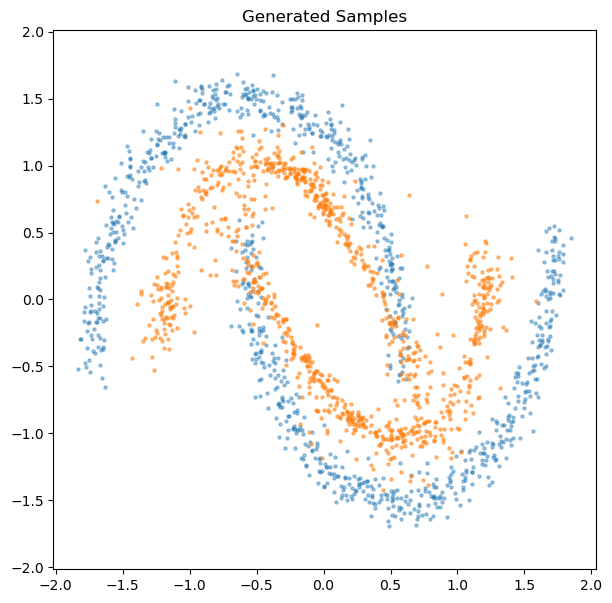

In [160]:
@torch.no_grad()
def sample_flow(model, n_samples=1000, n_steps=500):
    x = sample_noise(n_samples).to(device)
    dt = 1.0 / n_steps
    for step in range(n_steps):
        t = torch.ones(n_samples, device=device) * (step / n_steps)
        v = model(x, t)
        x = x + v * dt  # Euler integration
    return x.cpu().numpy()

samples = sample_flow(model)

plt.figure(figsize=(7, 7))
plt.scatter(X[:,0], X[:,1], s=5, label="Data", alpha=0.4)
plt.scatter(samples[:, 0], samples[:, 1], s=5, alpha=0.5)
plt.title("Generated Samples")
plt.axis("equal")
plt.show()


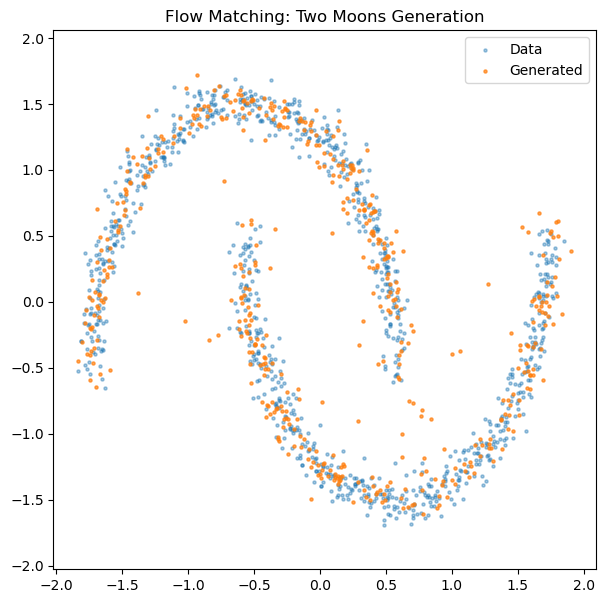

In [164]:
@torch.no_grad()
def generate_samples(n_samples=500, steps=20):
    x = sample_noise(n_samples).to(device)
    t_steps = torch.linspace(1, 0, steps+1).to(device)
    for i in range(steps):
        t = t_steps[i].repeat(n_samples)
        flow = model(x, t)
        delta_t = t_steps[i+1] - t_steps[i]
        x = x - flow * delta_t
    return x.cpu().numpy()

samples = generate_samples()

plt.figure(figsize=(7,7))
plt.scatter(X[:,0], X[:,1], s=5, label="Data", alpha=0.4)
plt.scatter(samples[:,0], samples[:,1], s=5, label="Generated", alpha=0.7)
plt.legend()
plt.title("Flow Matching: Two Moons Generation")
plt.axis("equal")
plt.show()


ValueError: Argument U has a size 800 which does not match 400, the number of arrow positions

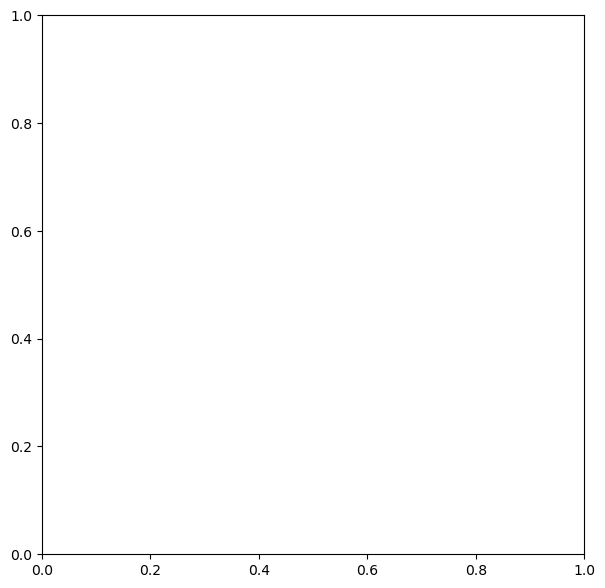

In [154]:
# --- Colab cell 7: (Bonus) Visualize Flow Field

def plot_flow_field(model, t_value=0.5, grid_size=20):
    grid_x, grid_y = np.meshgrid(np.linspace(-2, 3, grid_size), np.linspace(-1, 2, grid_size))
    pts = np.stack([grid_x.flatten(), grid_y.flatten()], axis=-1)
    pts_torch = torch.tensor(pts, dtype=torch.float32).to(device)
    t = torch.full((grid_size**2, 1), t_value, device=device)
    with torch.no_grad():
        flows = model(pts_torch, t).cpu().numpy()
    plt.figure(figsize=(7,7))
    plt.quiver(pts[:,0], pts[:,1], flows[:,0], flows[:,1], angles='xy', scale_units='xy', scale=10)
    plt.scatter(X[:,0], X[:,1], s=3, alpha=0.3)
    plt.title(f"Flow field at t={t_value}")
    plt.axis("equal")
    plt.show()

plot_flow_field(model, t_value=0.5)
